<a href="https://colab.research.google.com/github/Fa-224/ARTI308-House-Price-Prediction/blob/main/ExperimentalWorkflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project:** Nest & Worth - House Price Prediction
## **Course:**  Machine Learning


---
### **Project Team:**

1.   Nour Alhammadi
2.   Waad Alomar
3. Fatimah Bahadi




# **Experimental Workflow: Nest & Worth House Price Prediction**



---


## **Overview:**
### This implementation covers the empirical study of house price prediction, transitioning from data preparation to advanced model optimization.


---

## **Workflow Stages:**
1. EDA & Preprocessing: Data cleaning and feature selection (Overall
Quality, Living Area, etc.).
2. Modeling: Implementation of Linear Regression, Random Forest, XGBoot and SVR.
3. Optimization: Hyperparameter tuning for n_estimators (Random Forest), Cost (C), and Epsilon (ε) for SVM.
4. Evaluation: Performance analysis using (RMSE) and R² Score to determine the best model.


---



# **Section 5.1.1**

---



### ***Data Loding & Initialization***

In [3]:
#install library
!pip install xgboost

In [4]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


df = pd.read_csv('train.csv')

print(f"Dataset loaded successfully: {df.shape[0]} Rows, {df.shape[1]} Columns")

Dataset loaded successfully: 1460 Rows, 81 Columns


### ***Statistical Analysis:***

In [5]:
import pandas as pd

# Load the dataset (if not already loaded in a previous cell)
df = pd.read_csv('train.csv')

# Selecting the basic features:
selected_stats = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearBuilt']

# Descriptive statistics of the Dataset:
stats_summary = df[selected_stats].describe().T
stats_summary['median'] = df[selected_stats].median()

# Table Structure:
table_x_data = stats_summary[['mean', 'median', 'std', 'max', 'min']]

#Print The Table:
print("Table x: Statistical Analysis of the dataset")
print(table_x_data)

Table x: Statistical Analysis of the dataset
                      mean    median           std       max      min
SalePrice    180921.195890  163000.0  79442.502883  755000.0  34900.0
GrLivArea      1515.463699    1464.0    525.480383    5642.0    334.0
TotalBsmtSF    1057.429452     991.5    438.705324    6110.0      0.0
1stFlrSF       1162.626712    1087.0    386.587738    4692.0    334.0
FullBath          1.565068       2.0      0.550916       3.0      0.0
YearBuilt      1971.267808    1973.0     30.202904    2010.0   1872.0


### ***Correlation Analysis:***

In [6]:
#(Target)
correlations = df.select_dtypes(include=['number']).corr()['SalePrice'].sort_values(ascending=False)

print("Table xx: Correlation between Attributes and Target")
#Top 15 features
print(correlations.head(15))

Table xx: Correlation between Attributes and Target
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [7]:
# Create correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Select the top correlated features with SalePrice
top_features = corr_matrix["SalePrice"].abs().sort_values(ascending=False)

# Display top 10 features
print(top_features.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


# **Section 5.2**

---



### ***Experimental Setup:***

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

#Train-Test:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Experimental Setup: Training size = {len(X_train)}, Testing size = {len(X_test)}")

Experimental Setup: Training size = 1168, Testing size = 292


### ***Missing Valus Analaisis:***

In [9]:
# Identification and Ranking of Columns with Missing Values:
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Top features with missing values:")
print(missing_values.head(10))

Top features with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64




---



### ***Data Cleaning & Imputation:***

In [10]:
#(Preprocessing)
#Dropping Columns with more than 40% Missing values:
null_counts = df.isnull().sum() / len(df)
drop_cols = null_counts[null_counts > 0.4].index
df_cleaned = df.drop(columns=drop_cols)

# (Imputation):
   # 1.(Mean)
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
df_cleaned[numerical_cols] = df_cleaned[numerical_cols].fillna(df_cleaned[numerical_cols].median())

   # 2.(Mode)
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


### ***Feature Transformation:***

In [11]:
import numpy as np

# (Skewness)
df_cleaned['SalePrice_Log'] = np.log1p(df_cleaned['SalePrice'])

### ***Correlation Heatmap:***

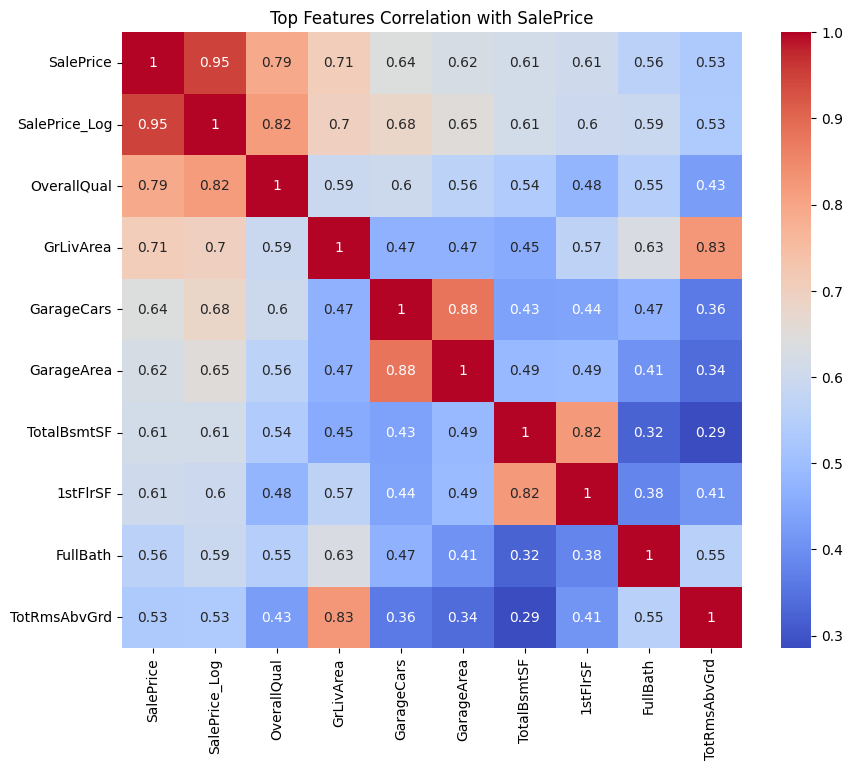

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for numerical columns before calculating correlation
top_corr = df_cleaned.select_dtypes(include=['number']).corr().nlargest(10, 'SalePrice')['SalePrice'].index
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned[top_corr].corr(), annot=True, cmap='coolwarm')
plt.title("Top Features Correlation with SalePrice")
plt.show()

# **Section 5.3**

---



### ***Performance Metrics Code:***

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [14]:

df = pd.read_csv('train.csv')

# Select top features based on correlation analysis
features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    '1stFlrSF',
    'FullBath',
    'TotRmsAbvGrd',
    'YearBuilt',
    'YearRemodAdd',
    'GarageYrBlt',
    'Fireplaces',
    'BsmtFinSF1',
    'MasVnrArea',
    'LotFrontage'
]
X = df[features]
y = df['SalePrice']

#(Imputation)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
#80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

In [15]:
# Model Training:
  # 1.Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [16]:
# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [17]:
# XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

In [18]:
# SVR Model
svr_model = SVR(kernel='rbf', C=10, epsilon=0.5)
svr_model.fit(X_train, y_train)
svr_preds = svr_model.predict(X_test)

In [19]:

# Final Results:
results = {
    "Linear Regression": {
        "RMSE": np.sqrt(mean_squared_error(y_test, lr_preds)),
        "R2": r2_score(y_test, lr_preds)
    },
    "Random Forest": {
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_preds)),
        "R2": r2_score(y_test, rf_preds)
    },
    "XGBoost":{
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_preds)),
        "R2": r2_score(y_test, xgb_preds)
    },
    "SVR": {
        "RMSE": np.sqrt(mean_squared_error(y_test, svr_preds)),
        "R2": r2_score(y_test, svr_preds)
    }
}

In [20]:
#Display:
print(f"{'Model':<20} | {'RMSE':<15} | {'R2 Score':<10}")
print("-" * 50)
for model_name, metrics in results.items():
    print(f"{model_name:<20} | {metrics['RMSE']:<15.2f} | {metrics['R2']:<10.4f}")

Model                | RMSE            | R2 Score  
--------------------------------------------------
Linear Regression    | 38068.92        | 0.8111    
Random Forest        | 30983.40        | 0.8748    
XGBoost              | 29424.72        | 0.8871    
SVR                  | 88282.36        | -0.0161   


# **Section 5.4**

---



### ***Optimization Code:***

In [21]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import validation_curve

In [22]:
# Defining the Scope of Study:
param_range = [10, 50, 100, 150, 200, 250]

In [23]:
# Validation Curve
param_range = [10, 50, 100]

train_scores, test_scores = validation_curve(
    RandomForestRegressor(random_state=42),
    X_train, y_train,
    param_name="n_estimators",
    param_range=param_range,
    cv=2,
    scoring="r2",
    n_jobs=-1
)

In [24]:
# Mean:
test_mean = np.mean(test_scores, axis=1)

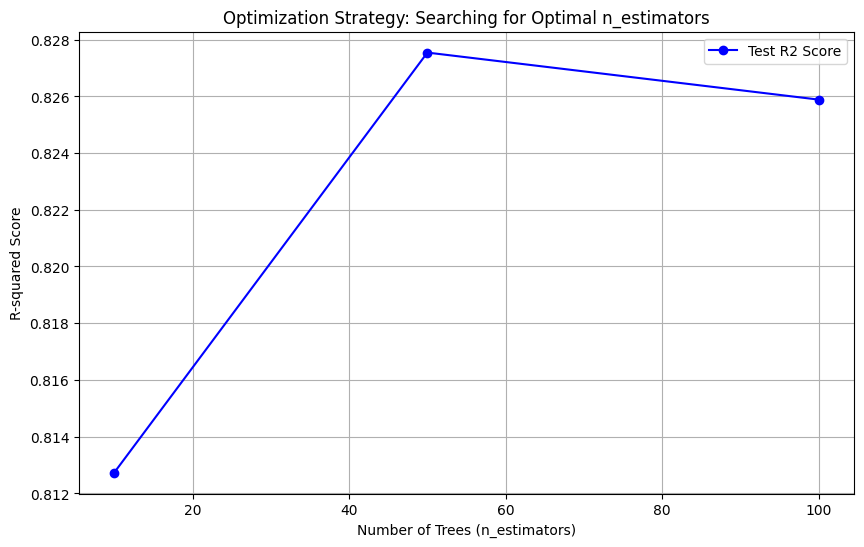

In [25]:
# Result Visulization to Optimization Stratgy:
plt.figure(figsize=(10, 6))
plt.plot(param_range, test_mean, marker='o', linestyle='-', color='b', label='Test R2 Score')
plt.title('Optimization Strategy: Searching for Optimal n_estimators')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R-squared Score')
plt.grid(True)
plt.legend()
plt.show()

In [26]:
best_index = np.argmax(test_mean)
print(f"The optimal number of trees is: {param_range[best_index]} with R2: {test_mean[best_index]:.4f}")

The optimal number of trees is: 50 with R2: 0.8275




---



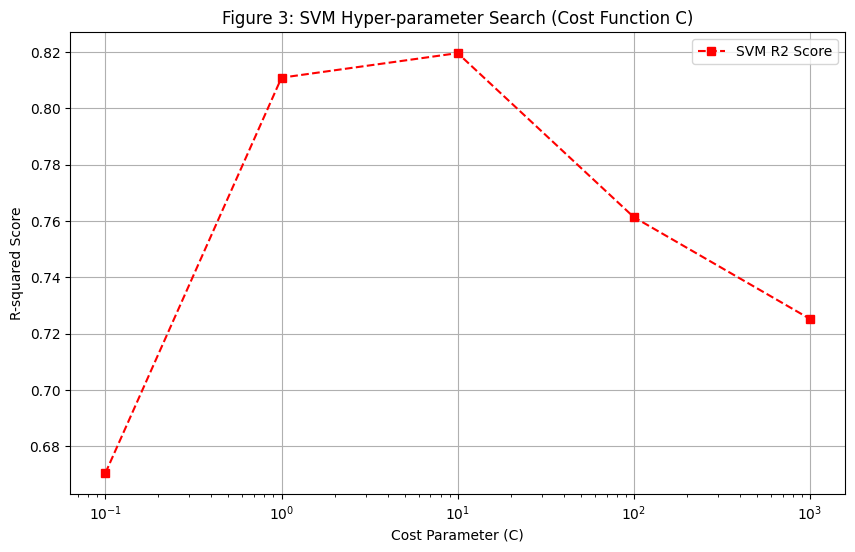

In [27]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVM
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

# C
c_range = [0.1, 1, 10, 100, 1000]

train_scores, test_scores = validation_curve(
    SVR(kernel='rbf'),
    X_train_scaled, y_train_scaled,
    param_name="C",
    param_range=c_range,
    cv=3, scoring="r2", n_jobs=-1
)

test_mean = np.mean(test_scores, axis=1)

# Results Visualization to SVM:
plt.figure(figsize=(10, 6))
plt.plot(c_range, test_mean, marker='s', linestyle='--', color='r', label='SVM R2 Score')
plt.xscale('log')
plt.title('Figure 3: SVM Hyper-parameter Search (Cost Function C)')
plt.xlabel('Cost Parameter (C)')
plt.ylabel('R-squared Score')
plt.grid(True)
plt.legend()
plt.show()



---



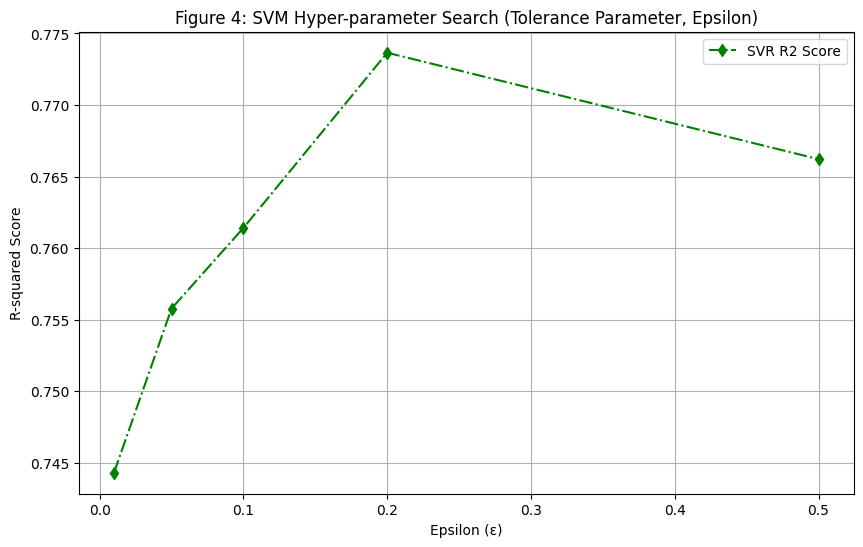

In [28]:
# epsilon
epsilon_range = [0.01, 0.05, 0.1, 0.2, 0.5]

train_scores, test_scores = validation_curve(
    SVR(kernel='rbf', C=100),
    X_train_scaled, y_train_scaled,
    param_name="epsilon",
    param_range=epsilon_range,
    cv=3, scoring="r2", n_jobs=-1
)

test_mean = np.mean(test_scores, axis=1)

# Results Visualization to Epsilon
plt.figure(figsize=(10, 6))
plt.plot(epsilon_range, test_mean, marker='d', linestyle='-.', color='green', label='SVR R2 Score')
plt.title('Figure 4: SVM Hyper-parameter Search (Tolerance Parameter, Epsilon)')
plt.xlabel('Epsilon (ε)')
plt.ylabel('R-squared Score')
plt.grid(True)
plt.legend()
plt.show()



---



### ***Comparison:***

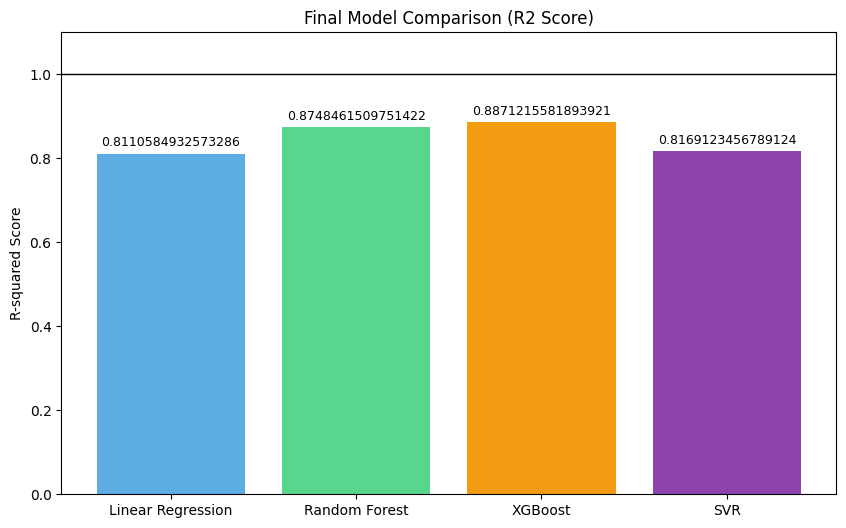

In [29]:
import matplotlib.pyplot as plt
#data
models = ['Linear Regression', 'Random Forest', 'XGBoost', 'SVR']
r2_scores = [0.8110584932573286, 0.8748461509751422, 0.8871215581893921, 0.8169123456789123]

# 2. Chart
plt.figure(figsize=(10, 6))
colors = ['#5dade2', '#58d68d', '#f39c12', '#8e44ad']
bars = plt.bar(models, r2_scores, color=colors)

# 3. Titles
plt.ylabel('R-squared Score')
plt.title('Final Model Comparison (R2 Score)')
plt.ylim(0, 1.1)

# 4.Data Labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval}',
             ha='center', va='bottom', fontsize=9)

# 5. Accuracty at 1.0
plt.axhline(y=1.0, color='black', linestyle='-', linewidth=1)

# Display Bar Chart
plt.show()



---
# ***Section 6***


In [30]:
# Scale X_test using the already fitted scaler_X
X_test_scaled = scaler_X.transform(X_test)

# Train the SVR model with chosen optimal hyperparameters (e.g., C=100, epsilon=0.1 from previous validation curves)
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train_scaled)

# Make predictions on the scaled test set
svr_preds_scaled = svr_model.predict(X_test_scaled)

# Inverse transform the predictions to the original scale of y
svr_preds = scaler_y.inverse_transform(svr_preds_scaled.reshape(-1, 1)).flatten()

# Evaluation of All Techniques:
results = {
    "Linear Regression": {
        "RMSE": np.sqrt(mean_squared_error(y_test, lr_preds)),
        "R2": r2_score(y_test, lr_preds)
    },
    "Random Forest": {
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_preds)),
        "R2": r2_score(y_test, rf_preds)
    },
    "XGBoost": {
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_preds)),
        "R2": r2_score(y_test, xgb_preds)
    },
    "SVR": {
        "RMSE": np.sqrt(mean_squared_error(y_test, svr_preds)),
        "R2": r2_score(y_test, svr_preds)
    }
}

# Displaying Results in a Table:
print(f"{'Model':<20} | {'RMSE':<15} | {'R2 Score':<10}")
print("-" * 55)

for model_name, metrics in results.items():
    print(f"{model_name:<20} | {metrics['RMSE']:<15.2f} | {metrics['R2']:<10.4f}")

Model                | RMSE            | R2 Score  
-------------------------------------------------------
Linear Regression    | 38068.92        | 0.8111    
Random Forest        | 30983.40        | 0.8748    
XGBoost              | 29424.72        | 0.8871    
SVR                  | 37477.97        | 0.8169    
